# Visualisatie van examenprestaties van studenten met 3D-oppervlakken en spreidingsdiagrammen (PROC G3D)

## Managementsamenvatting

Dit notebook gebruikt **PROC G3D** om te visualiseren hoe twee
onderwijsinterventiefactoren gezamenlijk de leerresultaten van studenten
vormgeven in een onderwijsanalytische omgeving. Een volledig factorieel
raster stuurt een vloeiend responsoppervlak van voorspelde examenscores over
wekelijkse zelfstudie-uren (0 tot 20) en GPA vorig semester (0 tot 4), en een
synthetisch cohort van 100 studenten wordt weergegeven als **3D-spreidings**panelen
opgesplitst per prestatieniveau.

Het gefitte oppervlak stijgt van een voorspelde score rond 26 bij nul
studie-uren naar een plafond rond 99, en vlakt af zodra de studie-uren
ongeveer 10 passeren — de richel van afnemende meeropbrengst die het model
vastlegt. De studentenpanelen bevestigen het patroon op individueel niveau:
de 20 studenten *met onderscheiding* (elk met een score van 85 of hoger)
bevinden zich in de hoek met hoge GPA en meer studie-uren, terwijl de 33
studenten *in de risicogroep* zich concentreren in het gebied met weinig
inzet en lage GPA. Een met WHERE gefilterde weergave van die hoek isoleert 35
studenten voor wie bescheiden toenames in studietijd de grootste marginale
winst opleveren.

## Gegevensbronnen

Alle gegevens worden inline gegenereerd met `call streaminit()` en `rand()`
— geen externe bestanden of netwerktoegang.

**`score_grid`** — volledig factorieel raster dat het responsoppervlak
stuurt (één rij per cel studie-uren x GPA vorig semester, 99 rijen).

| Variabele | Type | Omschrijving |
|----------|------|-------------|
| `study_hours` | Num | Wekelijkse zelfstudie-uren, 0 tot 20 in stappen van 2 (X-as) |
| `prior_gpa` | Num | GPA vorig semester op een schaal van 0–4 (Y-as) |
| `pred_score` | Num | Gemodelleerde eindexamenscore 0–100 uit een verzadigend responsmodel (Z-as) |

**`students`** — synthetisch individueel studentencohort voor het
spreidingsdiagram (100 rijen).

| Variabele | Type | Omschrijving |
|----------|------|-------------|
| `student_id` | Num | Opeenvolgende studentidentificatie |
| `study_hours` | Num | Waargenomen wekelijkse zelfstudie-uren (X-as) |
| `prior_gpa` | Num | Waargenomen GPA vorig semester (Y-as) |
| `exam_score` | Num | Waargenomen eindexamenscore 0–100 (Z-as) |
| `cohort` | Char | Inschrijvingscohort, `Herfst` of `Lente` |
| `band` | Char | Prestatieniveau: `Onderscheiding` (≥85), `Voldoende` (65–84), `Risicogroep` (<65) |

Het raster is bewust op 99 cellen gehouden zodat het het volledige bereik van
0–20 studie-uren en 0–4 GPA bestrijkt terwijl het binnen de
100-observatielimiet van deze omgeving blijft; een 11 x 9-rooster houdt het
oppervlak vloeiend zonder een van beide assen af te knotten.

# Visualisatie van examenprestaties van studenten met PROC G3D

Onderwijsonderzoekers willen vaak begrijpen hoe twee beïnvloedbare factoren
gezamenlijk een uitkomst sturen. Hier stellen we de vraag: *hoe combineren
wekelijkse studie-uren en de GPA van een student uit het vorige semester om
de eindexamenprestatie te vormen?*

Een tweedimensionale grafiek kan geen interactieoppervlak tonen. **PROC G3D**
tekent echte driedimensionale grafieken van variabelen in de notatie
`y*x=z`, waarbij X en Y het horizontale vlak bestrijken en Z verticaal
stijgt. We gebruiken twee van de mogelijkheden:

- **PLOT** — een continu respons**oppervlak** over een volledig raster van
  de twee voorspellers.
- **SCATTER** — individuele studenten geplot als 3D-symbolen. We tekenen één
  paneel per prestatieniveau, elk met zijn eigen markeringskleur en -vorm,
  zodat de drie uitkomstniveaus eenvoudig te vergelijken zijn.

Alles hieronder draait op inline gegenereerde synthetische gegevens, dus het
notebook is volledig zelfstandig.

## Stap 1 — Genereer het raster voor het responsoppervlak

Een G3D-oppervlakteplot heeft een redelijk volledig raster nodig: het
vereist niet-ontbrekende Z-waarden voor ten minste de helft van de X-Y
cellen. We garanderen een *volledig* raster door twee `DO`-lussen te nesten
over `study_hours` (0 tot 20 in stappen van 2) en `prior_gpa` (0 tot 4 in
stappen van 0,5) — een 11 x 9-rooster van 99 cellen dat beide assen volledig
bestrijkt.

De voorspelde score volgt een plausibel verzadigend model: het rendement van
studeren neemt af bij veel uren, GPA vorig semester draagt ongeveer lineair
bij, en de twee interageren (een sterke student zet studietijd efficiënter
om in punten). Een kleine reproduceerbare ruis van `rand('NORMAL')` zorgt dat
het oppervlak er niet perfect analytisch uitziet. `call streaminit()` legt
de seed vast zodat het raster reproduceerbaar is.

In [1]:
GEGEVENS score_grid;
   CALL streaminit(20260531);
   DOE study_hours = 0 TOT 20 VOLGENS 2;     /* 11 waarden: volledig bereik 0-20 */
      DOE prior_gpa = 0 TOT 4 VOLGENS 0.5;   /* 9 waarden -> 99 rastercellen */
         /* verzadigend rendement op studie-uren */
         effort = 40 * (1 - EXP(-study_hours / 6));
         /* eerdere prestatie en een interactieterm */
         BASE   = 8 * prior_gpa;
         inter  = 1.1 * prior_gpa * (1 - EXP(-study_hours / 6));
         pred_score = 25 + effort + BASE + inter
                      + rand('NORMAL') * 1.5;
         ALS pred_score > 100 DAN pred_score = 100;
         ALS pred_score < 0   DAN pred_score = 0;
         UITVOER;
      EINDE;
   EINDE;
   BEWAREN study_hours prior_gpa pred_score;
UITVOEREN;

PROCEDURE GEMIDDELDEN GEGEVENS=score_grid n MIN mean MAX maxdec=1;
   VARIABELE study_hours prior_gpa pred_score;
   label study_hours = 'Wekelijkse zelfstudie-uren'
         prior_gpa   = 'GPA vorig semester'
         pred_score  = 'Voorspelde examenscore';
UITVOEREN;

                                                  The MEANS Procedure

 Variable     Label                             N     Minimum        Mean     Maximum
 ------------------------------------------------------------------------------------
 study_hours  Wekelijkse zelfstudie-uren       99         0.0        10.0        20.0
 prior_gpa    GPA vorig semester               99         0.0         2.0         4.0
 pred_score   Voorspelde examenscore           99        25.7        70.0        98.7
 ------------------------------------------------------------------------------------




NOTE: DATA score_grid


NOTE: Wrote score_grid (99 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


## Stap 2 — Teken het basisresponsoppervlak

Met een volledig raster in handen plot de eenvoudigste aanroep het oppervlak
met de standaardinstellingen van de procedure. De syntaxis `PLOT y*x=z`
koppelt `prior_gpa` aan de Y-as, `study_hours` aan de X-as, en de
voorspelde score aan de verticale Z-as.

We labelen de assen met een `LABEL`-statement en stellen titels en een
voetnoot in met de globale `TITLE`/`FOOTNOTE`-statements zodat de grafiek
overzichtelijk leest.

                                            Voorspeld examenscore-oppervlak                                             
                              Effect van wekelijkse zelfstudie-uren en GPA vorig semester                               

PROC G3D Output
Data: score_grid

Variables: Wekelijkse zelfstudie-uren, GPA vorig semester, Voorspelde examenscore

Wekelijkse zelfstudie-uren  GPA vorig semester  Voorspelde examenscore
--------------------------  ------------------  ----------------------
                         0                   0           25.7031536911
                         0                 0.5           28.9516502743
                         0                   1           32.3400787822
                         0                 1.5           36.8265757618
                         0                   2           40.7806886968
                         0                 2.5             42.61364606
                         0                   3           49.4289293966
 


NOTE: GOPTIONS RESET=GLOBAL (unrecognized, treating as GOPTIONS).
NOTE: GOPTIONS BORDER enabled.
NOTE: Option TITLE changed to Voorspeld examenscore-oppervlak.
NOTE: Option TITLE2 changed to Effect van wekelijkse zelfstudie-uren en GPA vorig semester.
NOTE: Option FOOTNOTE changed to Synthetische onderwijsanalysegegevens .
NOTE: PROC G3D data=score_grid

NOTE: ODS plot written: g3d_surface.spec.json


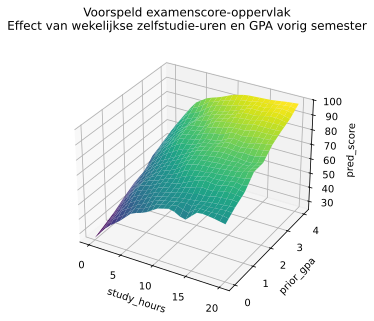

In [2]:
GOPTIONS reset=GLOBAL BORDER;

TITEL 'Voorspeld examenscore-oppervlak';
title2 'Effect van wekelijkse zelfstudie-uren en GPA vorig semester';
footnote j=r 'Synthetische onderwijsanalysegegevens ';

PROCEDURE g3d GEGEVENS=score_grid;
   PLOT prior_gpa*study_hours=pred_score;
   label study_hours = 'Wekelijkse zelfstudie-uren'
         prior_gpa   = 'GPA vorig semester'
         pred_score  = 'Voorspelde examenscore';
UITVOEREN;
QUIT;

## Stap 3 — Verfijn het oppervlak met weergave- en asopties

Enkele opties maken het oppervlak veel leesbaarder:

- **ROTATE=** en **TILT=** stellen de kijkhoek in (graden rond de Z-as, en
  kanteling naar de kijker toe).
- **XYTYPE=2** tekent oppervlaklijnen evenwijdig aan de Y-as, wat benadrukt
  hoe de score stijgt met studie-uren.
- **SIDE** voegt een zijwand toe voor een solide, gebeeldhouwd uiterlijk.
- **GRID** voegt referentielijnen toe bij de hoofdschaalstreepjes.
- **ZMIN=/ZMAX=** en de **ZTICKNUM=**-familie leggen de scoreas vast op het
  volledige bereik van 0–100 zodat het oppervlak niet visueel wordt
  overdreven, terwijl **XTICKNUM=/YTICKNUM=** de schaalstreepjes van het
  grondvlak regelen.
- **NAME=** en **DESCRIPTION=** labelen de grafiek in de uitvoercatalogus.

                                 Voorspeld examenscore-oppervlak (gestileerde weergave)                                 
                                          Geroteerd, gekanteld en asgeschaald                                           

PROC G3D Output
Data: score_grid

Variables: Wekelijkse zelfstudie-uren, GPA vorig semester, Voorspelde examenscore

Wekelijkse zelfstudie-uren  GPA vorig semester  Voorspelde examenscore
--------------------------  ------------------  ----------------------
                         0                   0           25.7031536911
                         0                 0.5           28.9516502743
                         0                   1           32.3400787822
                         0                 1.5           36.8265757618
                         0                   2           40.7806886968
                         0                 2.5             42.61364606
                         0                   3           49.4289293966
 


NOTE: Option TITLE changed to Voorspeld examenscore-oppervlak (gestileerde weergave).
NOTE: Option TITLE2 changed to Geroteerd, gekanteld en asgeschaald.
NOTE: PROC G3D data=score_grid

NOTE: ODS plot written: scoresurf.spec.json


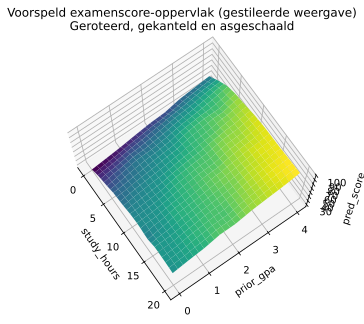

In [3]:
TITEL 'Voorspeld examenscore-oppervlak (gestileerde weergave)';
title2 'Geroteerd, gekanteld en asgeschaald';

PROCEDURE g3d GEGEVENS=score_grid;
   PLOT prior_gpa*study_hours=pred_score /
        ROTATE=55
        tilt=75
        xytype=2
        side
        grid
        zmin=0 zmax=100
        xticknum=5 yticknum=5 zticknum=6
        name="scoresurf"
        description="Gestileerd responsoppervlak examenscore";
   label study_hours = 'Wekelijkse zelfstudie-uren'
         prior_gpa   = 'GPA vorig semester'
         pred_score  = 'Voorspelde examenscore';
UITVOEREN;
QUIT;

## Stap 4 — Vergelijk het oppervlak vanuit verschillende kijkhoeken

Omdat een 3D-oppervlak structuur achter zijn eigen pieken kan verbergen,
helpt het om hetzelfde oppervlak vanuit meer dan één rotatie weer te geven.
Hier geven we drie PROC G3D-stappen op die een vaste kanteling delen maar de
**ROTATE=**-hoek doorlopen via 30, 90 en 150 graden, zodat de richel vanaf de
voorkant, de zijkant en de achterkant kan worden bekeken.

                                                    Responsoppervlak                                                    
                                            ROTATE = 30 bij vaste kanteling                                             

PROC G3D Output
Data: score_grid

Variables: Wekelijkse zelfstudie-uren, GPA vorig semester, Voorspelde examenscore

Wekelijkse zelfstudie-uren  GPA vorig semester  Voorspelde examenscore
--------------------------  ------------------  ----------------------
                         0                   0           25.7031536911
                         0                 0.5           28.9516502743
                         0                   1           32.3400787822
                         0                 1.5           36.8265757618
                         0                   2           40.7806886968
                         0                 2.5             42.61364606
                         0                   3           49.4289293966
 


NOTE: Option TITLE changed to Responsoppervlak.
NOTE: Option TITLE2 changed to ROTATE = 30 bij vaste kanteling.
NOTE: PROC G3D data=score_grid

NOTE: ODS plot written: surf_rot30.spec.json
NOTE: Option TITLE changed to Responsoppervlak.
NOTE: Option TITLE2 changed to ROTATE = 90 bij vaste kanteling.
NOTE: PROC G3D data=score_grid

NOTE: ODS plot written: surf_rot90.spec.json
NOTE: Option TITLE changed to Responsoppervlak.
NOTE: Option TITLE2 changed to ROTATE = 150 bij vaste kanteling.
NOTE: PROC G3D data=score_grid

NOTE: ODS plot written: surf_rot150.spec.json


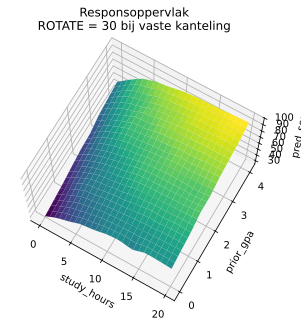

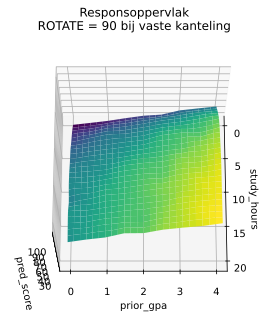

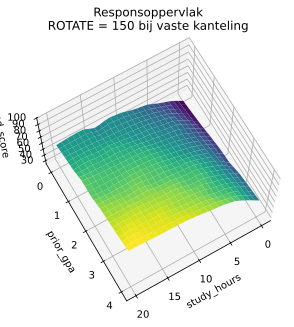

In [4]:
%macro angle(deg);
   TITEL 'Responsoppervlak';
   title2 "ROTATE = &deg bij vaste kanteling";
   PROCEDURE g3d GEGEVENS=score_grid;
      PLOT prior_gpa*study_hours=pred_score /
           ROTATE=&deg
           tilt=70
           xytype=3
           zmin=0 zmax=100
           name="surf_rot&deg";
      label study_hours = 'Wekelijkse zelfstudie-uren'
            prior_gpa   = 'GPA vorig semester'
            pred_score  = 'Voorspelde examenscore';
   UITVOEREN;
   QUIT;
%mend;

%angle(30);
%angle(90);
%angle(150);

## Stap 5 — Genereer een synthetisch studentencohort

Het oppervlak is een model; echte studenten spreiden zich eromheen. We
simuleren nu 100 individuele studenten uit twee inschrijvingscohorten
(`Herfst`, `Lente`). Elke student heeft waargenomen studie-uren, een GPA
vorig semester, en een ruizige gerealiseerde examenscore, gegenereerd uit
dezelfde responslogica plus grotere individuele variatie.

We leiden vervolgens een prestatieniveau **band** af uit de examenscore:
`Onderscheiding` (85 of hoger), `Voldoende` (65 tot 84), en `Risicogroep`
(onder 65). De PROC FREQ-kruistabel hieronder rapporteert hoe de niveaus
verdeeld zijn over de twee cohorten. `rand('UNIFORM')` en `rand('NORMAL')`
leveren de willekeur; de seed houdt het reproduceerbaar.

                                                    Responsoppervlak                                                    
                                            ROTATE = 150 bij vaste kanteling                                            

                                                   The FREQ Procedure

                                Cumulative
Prestatieniveau    Frequency    Frequency
---------------------------------------------
Onderscheiding            20           20
Risicogroep               33           53
Voldoende                 47          100

Table of Cohort by Prestatieniveau

Cohort |Onderscheiding |   Risicogroep |     Voldoende |          Total
-------+---------------+---------------+---------------+---------------
Herfst |             6 |            15 |            20 |             41
-------+---------------+---------------+---------------+---------------
Lente  |            14 |            18 |            27 |             59
-------+---------------+--------


NOTE: DATA students


NOTE: Wrote students (100 rows, 6 columns).
NOTE: DATA elapsed:
  wall  0.02 seconds
  cpu   0.02 seconds
NOTE: PROC FREQ
NOTE: ODS plot written: freq_band.spec.json
NOTE: ODS plot written: freq_mosaic_cohort_band.spec.json
NOTE: PROC FREQ statement used.


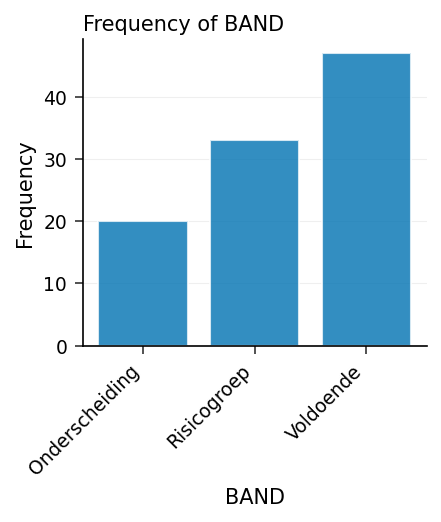

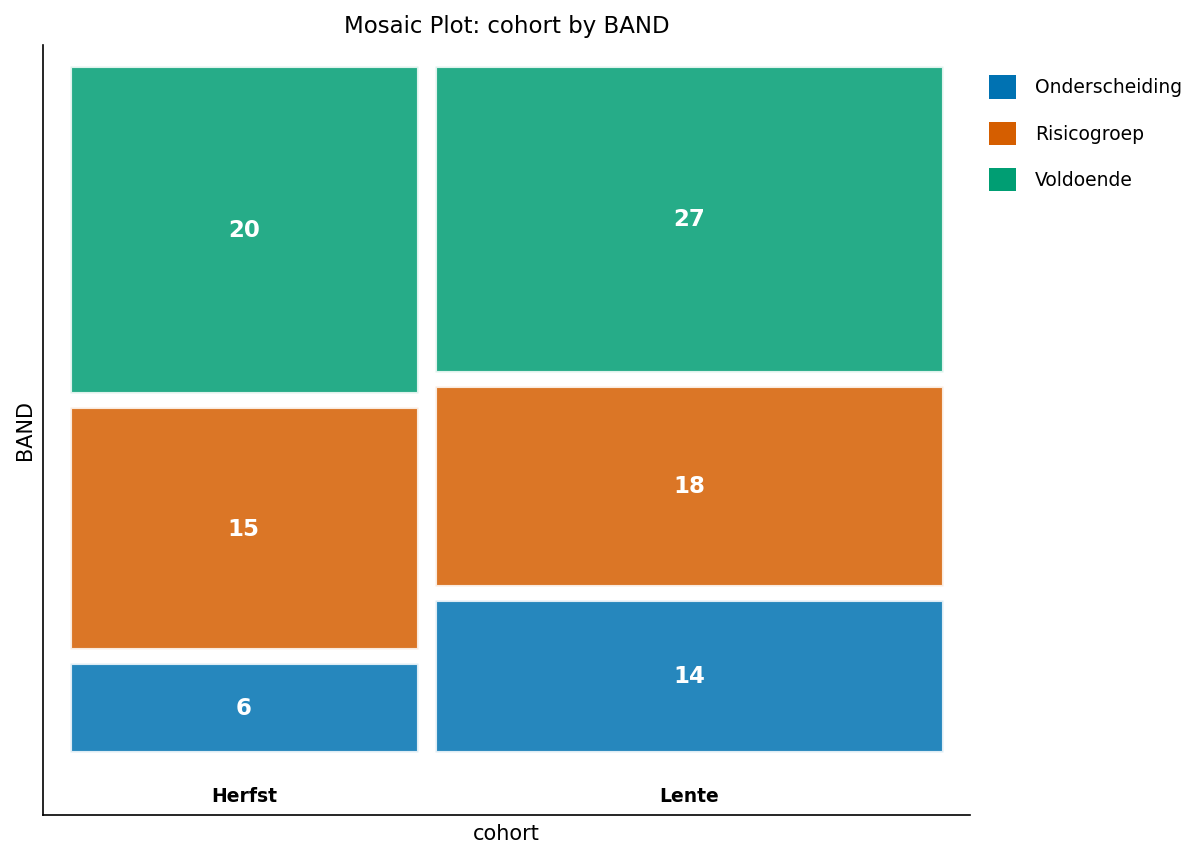

In [5]:
GEGEVENS students;
   CALL streaminit(99001);
   LENGTE cohort $6 BAND $14;
   DOE student_id = 1 TOT 100;
      ALS rand('UNIFORM') < 0.5 DAN cohort = 'Herfst';
      ANDERS cohort = 'Lente';

      study_hours = 20 * rand('UNIFORM');
      prior_gpa   = 4  * rand('UNIFORM');

      effort = 40 * (1 - EXP(-study_hours / 6));
      BASE   = 8 * prior_gpa;
      inter  = 1.1 * prior_gpa * (1 - EXP(-study_hours / 6));
      exam_score = 25 + effort + BASE + inter
                   + rand('NORMAL') * 7;
      ALS exam_score > 100 DAN exam_score = 100;
      ALS exam_score < 0   DAN exam_score = 0;

      ALS exam_score >= 85 DAN BAND = 'Onderscheiding';
      ANDERS ALS exam_score >= 65 DAN BAND = 'Voldoende';
      ANDERS BAND = 'Risicogroep';

      UITVOER;
   EINDE;
   BEWAREN student_id cohort study_hours prior_gpa exam_score BAND;
UITVOEREN;

PROCEDURE FREQUENTIES GEGEVENS=students;
   TABLES BAND cohort*BAND / nocol nopercent;
   label BAND='Prestatieniveau' cohort='Cohort';
UITVOEREN;

## Stap 6 — Plot studenten als 3D-spreidingspanelen per prestatieniveau

De **SCATTER**-statement plaatst elke student als een 3D-symbool. Om de
drie prestatieniveaus makkelijk leesbaar te maken, tekenen we één paneel per
niveau, elk gefilterd met **WHERE** en met een eigen letterlijke **COLOR=**
en **SHAPE=**: groene ruiten (`SHAPE=diamond`) voor *Onderscheiding*, blauwe
markeringen (`SHAPE=club`) voor *Voldoende*, en rode markeringen
(`SHAPE=spade`) voor *Risicogroep*. **SIZE=** vergroot de markeringen,
**GRID** voegt vloerreferentielijnen toe, **NONEEDLE** verwijdert de
verticale valstreepjes, en **ZMIN=/ZMAX=** houden elk paneel op dezelfde
0–100-scoreas zodat de drie weergaven direct vergelijkbaar zijn.

Elk niveau krijgt zijn eigen PROC G3D-stap zodat het WHERE-filter netjes van
toepassing is en de markeringsstijl ondubbelzinnig is.

                                              Studenten met onderscheiding                                              
                                                Examenscore 85 en hoger                                                 

PROC G3D Output
Data: students

Variables: Student-ID, Cohort, Wekelijkse zelfstudie-uren, GPA vorig semester, Examenscore, BAND

Student-ID      Cohort  Wekelijkse zelfstudie-uren  GPA vorig semester  Examenscore        BAND
----------  ----------  --------------------------  ------------------  -----------  ----------
         2       Lente               19.2134883194        2.6467742616  90.3663886999  Onderscheiding
         5       Lente               15.5520919174        2.7102003827  94.9419468332  Onderscheiding
        10       Lente               14.2302640951        3.8791496428          100  Onderscheiding
        17       Lente               13.7403346635        2.7462821708  89.6648779222  Onderscheiding
        25      Herfst       


NOTE: Option FOOTNOTE changed to Uit een cohort van 100 synthetische studenten .
NOTE: Option TITLE changed to Studenten met onderscheiding.
NOTE: Option TITLE2 changed to Examenscore 85 en hoger.
NOTE: PROC G3D data=students

NOTE: ODS plot written: band_honors.spec.json
NOTE: Option TITLE changed to Studenten met voldoende.
NOTE: Option TITLE2 changed to Examenscore 65 tot 84.
NOTE: PROC G3D data=students

NOTE: ODS plot written: band_pass.spec.json
NOTE: Option TITLE changed to Risicostudenten.
NOTE: Option TITLE2 changed to Examenscore onder 65.
NOTE: PROC G3D data=students

NOTE: ODS plot written: band_atrisk.spec.json


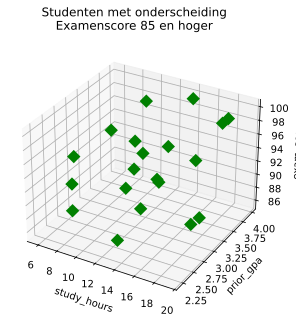

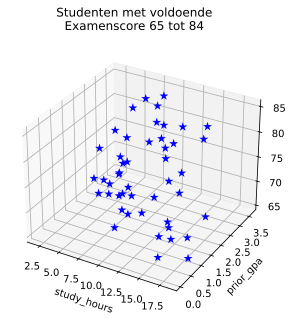

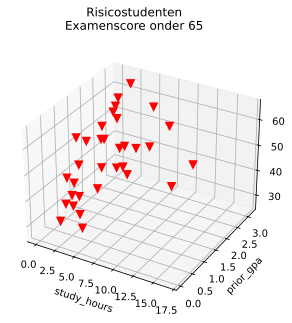

In [6]:
footnote j=r 'Uit een cohort van 100 synthetische studenten ';

/* Onderscheiding (exam_score >= 85): groene ruiten */
TITEL 'Studenten met onderscheiding';
title2 'Examenscore 85 en hoger';
PROCEDURE g3d GEGEVENS=students;
   SCATTER prior_gpa*study_hours=exam_score /
           color=green shape=diamond size=3
           noneedle grid zmin=0 zmax=100
           name="band_honors"
           description="Studenten met onderscheiding";
   WAAR BAND = 'Onderscheiding';
   label study_hours = 'Wekelijkse zelfstudie-uren'
         prior_gpa   = 'GPA vorig semester'
         exam_score  = 'Examenscore'
         cohort      = 'Cohort'
         band        = 'Prestatieniveau'
         student_id  = 'Student-ID';
UITVOEREN;
QUIT;

/* Voldoende (65 <= exam_score < 85): blauwe klavers */
TITEL 'Studenten met voldoende';
title2 'Examenscore 65 tot 84';
PROCEDURE g3d GEGEVENS=students;
   SCATTER prior_gpa*study_hours=exam_score /
           color=blue shape=club size=3
           noneedle grid zmin=0 zmax=100
           name="band_pass"
           description="Studenten met voldoende";
   WAAR BAND = 'Voldoende';
   label study_hours = 'Wekelijkse zelfstudie-uren'
         prior_gpa   = 'GPA vorig semester'
         exam_score  = 'Examenscore'
         cohort      = 'Cohort'
         band        = 'Prestatieniveau'
         student_id  = 'Student-ID';
UITVOEREN;
QUIT;

/* Risicogroep (exam_score < 65): rode schoppen */
TITEL 'Risicostudenten';
title2 'Examenscore onder 65';
PROCEDURE g3d GEGEVENS=students;
   SCATTER prior_gpa*study_hours=exam_score /
           color=red shape=spade size=3
           noneedle grid zmin=0 zmax=100
           name="band_atrisk"
           description="Risicostudenten";
   WAAR BAND = 'Risicogroep';
   label study_hours = 'Wekelijkse zelfstudie-uren'
         prior_gpa   = 'GPA vorig semester'
         exam_score  = 'Examenscore'
         cohort      = 'Cohort'
         band        = 'Prestatieniveau'
         student_id  = 'Student-ID';
UITVOEREN;
QUIT;

## Stap 7 — Aparte spreidingsdiagrammen per inschrijvingscohort (BY-groep)

Programmaleiders hebben vaak dezelfde weergave nodig, opgesplitst per
cohort. De **BY**-statement produceert één spreidingsdiagram per cohort.
G3D verwacht dat BY-groepgegevens gesorteerd zijn, dus sorteren we eerst met
PROC SORT. Elk cohort krijgt vervolgens zijn eigen gelabelde 3D-spreidings-
diagram op een gedeelde 0–100-scoreas, zodat de Herfst- en
Lente-verdelingen eenvoudig naast elkaar te vergelijken zijn.

                                        Examenresultaten per inschrijvingscohort                                        
                                  Eén 3D-spreidingsdiagram per cohort (Herfst, Lente)                                   

PROC G3D Output
Data: students_sorted

Variables: Student-ID, Cohort, Wekelijkse zelfstudie-uren, GPA vorig semester, Examenscore, BAND

Student-ID      Cohort  Wekelijkse zelfstudie-uren  GPA vorig semester  Examenscore        BAND
----------  ----------  --------------------------  ------------------  -----------  ----------
        52      Herfst               15.2586640362        0.4602308374  55.5186804916  Risicogroep
        13      Herfst                5.8493366471        1.8449001873  70.6084324429   Voldoende
        15      Herfst                5.5070892672        1.4478111608  70.0069314398   Voldoende
        22      Herfst                0.0365105382        1.3187236247  35.9197853017  Risicogroep
        24      Herfst            


NOTE: PROC SORT data=students

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 100 rows from students.
NOTE: Wrote students_sorted (100 rows, 6 columns).
NOTE: PROC SORT statement used.
NOTE: Option TITLE changed to Examenresultaten per inschrijvingscohort.
NOTE: Option TITLE2 changed to Eén 3D-spreidingsdiagram per cohort (Herfst, Lente).
NOTE: Option FOOTNOTE changed to Eén paneel per cohort .
NOTE: PROC G3D data=students_sorted

NOTE: ODS plot written: cohort_scatter_by1.spec.json
NOTE: ODS plot written: cohort_scatter_by2.spec.json


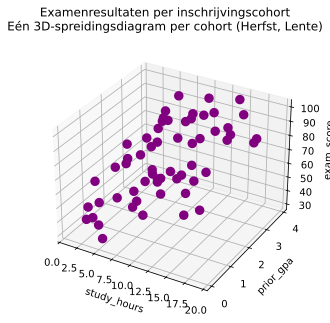

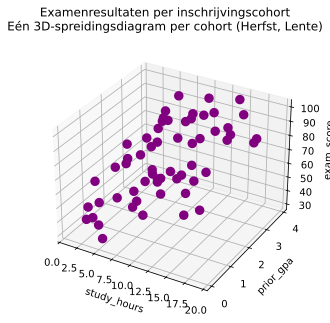

In [7]:
PROCEDURE SORTEREN GEGEVENS=students out=students_sorted;
   VOLGENS cohort;
UITVOEREN;

TITEL 'Examenresultaten per inschrijvingscohort';
title2 'Eén 3D-spreidingsdiagram per cohort (Herfst, Lente)';
footnote j=r 'Eén paneel per cohort ';

PROCEDURE g3d GEGEVENS=students_sorted;
   VOLGENS cohort;
   SCATTER prior_gpa*study_hours=exam_score /
           color=purple
           shape=balloon
           size=3
           grid
           zmin=0 zmax=100
           name="cohort_scatter";
   label study_hours = 'Wekelijkse zelfstudie-uren'
         prior_gpa   = 'GPA vorig semester'
         exam_score  = 'Examenscore'
         cohort      = 'Cohort'
         band        = 'Prestatieniveau'
         student_id  = 'Student-ID';
UITVOEREN;
QUIT;

## Stap 8 — Focus op de risicogroep met WHERE

Voor interventieplanning is de meest bruikbare weergave de linkeronderkant
van het oppervlak: studenten met zowel bescheiden studietijd (8 uur of
minder) als lagere GPA vorig semester (2,5 of lager). De
**WHERE**-statement beperkt het spreidingsdiagram tot dat gebied voordat er
geplot wordt. De listing toont dat deze hoek 35 van de 100 studenten bevat —
22 daarvan al *in de risicogroep* — zodat begeleiders precies kunnen zien
welke worstelende studenten het verst onder de verwachting zitten.

                               Interventiefocus: studenten met minder inzet en lagere GPA                               
                                         study_hours <= 8 and prior_gpa <= 2.5                                          

PROC G3D Output
Data: students

Variables: Student-ID, Cohort, Wekelijkse zelfstudie-uren, GPA vorig semester, Examenscore, BAND

Student-ID      Cohort  Wekelijkse zelfstudie-uren  GPA vorig semester  Examenscore        BAND
----------  ----------  --------------------------  ------------------  -----------  ----------
         1      Herfst                4.9780700766         1.072086769  59.409228777  Risicogroep
         7       Lente                7.9015823058        1.6623636789  66.9055021729   Voldoende
         9       Lente                2.5008494545        0.3621033759  48.1183184446  Risicogroep
        11       Lente                7.1907276895        2.1821388818  79.351887155   Voldoende
        13      Herfst                5.849


NOTE: Option TITLE changed to Interventiefocus: studenten met minder inzet en lagere GPA.
NOTE: Option TITLE2 changed to study_hours <= 8 and prior_gpa <= 2.5.
NOTE: Option FOOTNOTE changed to Naaldlijnen laten elke markering zakken naar het vlak van studie-uren x GPA .
NOTE: PROC G3D data=students

NOTE: ODS plot written: g3d_scatter.spec.json


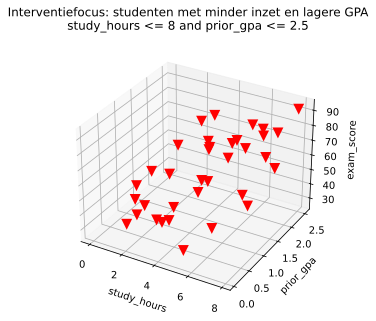

In [8]:
TITEL 'Interventiefocus: studenten met minder inzet en lagere GPA';
title2 'study_hours <= 8 and prior_gpa <= 2.5';
footnote j=r 'Naaldlijnen laten elke markering zakken naar het vlak van studie-uren x GPA ';

PROCEDURE g3d GEGEVENS=students;
   SCATTER prior_gpa*study_hours=exam_score /
           color=red
           shape=spade
           size=4
           grid
           zmin=0 zmax=100;
   WAAR study_hours <= 8 AND prior_gpa <= 2.5;
   label study_hours = 'Wekelijkse zelfstudie-uren'
         prior_gpa   = 'GPA vorig semester'
         exam_score  = 'Examenscore'
         cohort      = 'Cohort'
         band        = 'Prestatieniveau'
         student_id  = 'Student-ID';
UITVOEREN;
QUIT;

## Interpretatie van de resultaten

Het **responsoppervlak** (Stap 2–4) toont een duidelijke verzadigende
richel. Over het raster van 99 cellen loopt de voorspelde score van ongeveer
26 (nul studie-uren, nul GPA) tot ongeveer 99 (de hoek met veel uren en hoge
GPA), met een rastergemiddelde van bijna 70. Langs de as van studie-uren
gelezen, stijgen de scores steil van 0 tot ongeveer 10 uur en vlakken ze
daarna af doordat extra uren afnemende meeropbrengst geven; langs de
GPA-as gelezen verschuift eerdere prestatie het hele oppervlak omhoog. De
interactieterm maakt de meeropbrengst van studie-uren iets steiler voor
sterkere studenten, wat verklaart waarom het oppervlak naar zijn verste hoek
kantelt in plaats van als een vlak vlak te stijgen.

De **studentenpanelen** (Stap 6–7) bevestigen dat het model ook voor
individuen opgaat. Het cohort van 100 splitst zich in 20 studenten *met
onderscheiding*, 47 met *voldoende*, en 33 *in de risicogroep*. In de
niveaupanelen bevinden de 20 groene ruiten *met onderscheiding* — elk met
een score van 85 of hoger — zich bij een GPA vorig semester van 2,2 of
hoger en bij ten minste ongeveer 6 wekelijkse studie-uren, geclusterd
rechtsboven in het grondvlak. De 33 rode markeringen *in de risicogroep*
concentreren zich in het gebied met weinig inzet en lage GPA, precies de
vallei van het oppervlak. Opsplitsing per cohort toont dat de verdelingen
van Herfst (41 studenten) en Lente (59 studenten) grotendeels vergelijkbaar
zijn, wat erop wijst dat de uitkomsten worden gestuurd door de twee
factoren eerder dan door het inschrijvingsmoment.

De **met WHERE gefilterde weergave** (Stap 8) isoleert de
interventiepopulatie: de 35 studenten met 8 of minder studie-uren en een GPA
van 2,5 of lager. Tweeëntwintig zitten al *in de risicogroep* en slechts
één bereikt *onderscheiding*. Binnen deze hoek stijgen de gerealiseerde
scores nog zichtbaar met studie-uren — een concreet, visueel argument dat
bescheiden toenames in gestructureerde studietijd de grootste marginale
winst opleveren precies waar ze het hardst nodig zijn.

Samengenomen verandert PROC G3D een tweefactor-interactiemodel in een
intuïtief, besluitvaardig beeld voor een onderwijsprogramma: waar het
scoreplafond ligt, wie eronder blijft, en waar begeleidingsinspanning het
meest oplevert.

> **Implementatienotitie.** SAS/GRAPH staat ook toe dat een enkele
> SCATTER-statement elke markering kleurt en vormt vanuit
> per-observatievariabelen (`COLOR=<charvar>`, `SHAPE=<charvar>`). Die
> per-observatievorm wordt in deze engine nog niet gerenderd, dus dit
> notebook tekent in plaats daarvan één letterlijk gekleurd paneel per
> niveau — een gelijkwaardige, volledig werkende weergave. De lacune wordt
> gevolgd door de gebankte regressietest
> `tests/401000_nb_g3d_scatter_color_variable_unrendered`.